# Customer Churn and Sales Trend Analysis

**Dataset:** UCI Machine Learning Repository — Online Retail  
**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn  
**Goal:** Turn transaction-level e-commerce data into sales trends, customer segments, a transparent churn-risk proxy, and concrete business actions.

This notebook is designed to run end to end. It:

1. Loads and audits a real retail transaction dataset.
2. Cleans transactions and engineers revenue and calendar features.
3. Builds monthly revenue, order, country, product, and day/time views.
4. Creates customer-level RFM metrics and actionable segments.
5. Estimates churn risk from recency, with the limitation clearly stated.
6. Summarizes findings and recommendations using the computed results.

> **Important interpretation note:** the dataset contains roughly one year of observed activity, so "churn" is treated as a **proxy**: a customer with no completed purchase in the last 90 days of the observation window. It is not a confirmed permanent churn label.


## 1. Setup and reproducibility

The workbook is included in `data/Online_Retail.xlsx`. If it is not present, the next cell downloads the original UCI archive automatically. Charts are saved under `outputs/` as well as displayed inline.


In [1]:
from pathlib import Path
import zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "Online_Retail.xlsx"
SOURCE_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

if not DATA_PATH.exists():
    print("Local workbook not found; downloading the UCI archive...")
    archive_path = DATA_DIR / "online_retail.zip"
    archive_path.write_bytes(urlopen(SOURCE_URL, timeout=60).read())
    with zipfile.ZipFile(archive_path) as archive:
        workbook_name = next(name for name in archive.namelist() if name.endswith(".xlsx"))
        DATA_PATH.write_bytes(archive.read(workbook_name))

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110

print(f"Workbook: {DATA_PATH}")
print(f"Size: {DATA_PATH.stat().st_size / 1_000_000:.1f} MB")


Workbook: data/Online_Retail.xlsx
Size: 23.7 MB


## 2. Load the raw data and assess data quality

In [2]:
raw = pd.read_excel(DATA_PATH)
raw.columns = (
    raw.columns.str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^0-9A-Za-z_]", "", regex=True)
)

raw["InvoiceNo"] = raw["InvoiceNo"].astype("string").str.strip()
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
raw["CustomerID"] = raw["CustomerID"].astype("string").str.strip()

quality = pd.DataFrame(
    {
        "Metric": [
            "Raw rows",
            "Raw columns",
            "Unique invoices",
            "Unique customers (including missing)",
            "Missing CustomerID rows",
            "Missing Description rows",
            "Cancelled invoice rows",
            "Duplicate rows",
            "Earliest invoice date",
            "Latest invoice date",
        ],
        "Value": [
            len(raw),
            raw.shape[1],
            raw["InvoiceNo"].nunique(),
            raw["CustomerID"].nunique(dropna=True),
            raw["CustomerID"].isna().sum(),
            raw["Description"].isna().sum(),
            raw["InvoiceNo"].str.startswith("C", na=False).sum(),
            raw.duplicated().sum(),
            raw["InvoiceDate"].min(),
            raw["InvoiceDate"].max(),
        ],
    }
)
display(quality)
display(raw.head())
display(raw.isna().mean().sort_values(ascending=False).rename("Missing share").to_frame())


,Metric,Value
0,Raw rows,541909
1,Raw columns,8
2,Unique invoices,25900
3,Unique customers (including missing),4372
4,Missing CustomerID rows,135080
5,Missing Description rows,1454
6,Cancelled invoice rows,9288
7,Duplicate rows,5268
8,Earliest invoice date,2010-12-01 08:26:00
9,Latest invoice date,2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


,Missing share
CustomerID,0.25
Description,0.00
StockCode,0.00
InvoiceNo,0.00
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
Country,0.00


### Cleaning decisions

- Cancelled invoices are excluded from sales and customer behavior metrics.
- Rows without a customer ID cannot support customer retention analysis, so they are excluded from customer-level views.
- Rows with missing descriptions, non-positive quantities, or non-positive unit prices are excluded from completed sales.
- Duplicate rows are reported, not blindly removed: in transactional exports a repeated line can represent a valid repeated item line, and the notebook uses invoice-level aggregation for orders.


In [3]:
raw["InvoiceStatus"] = np.where(
    raw["InvoiceNo"].str.startswith("C", na=False), "Cancelled", "Completed"
)

sales = raw.loc[
    (raw["InvoiceStatus"] == "Completed")
    & raw["CustomerID"].notna()
    & raw["Description"].notna()
    & (raw["Quantity"] > 0)
    & (raw["UnitPrice"] > 0)
].copy()

sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]

# Date extraction and business-friendly features.
sales["InvoiceMonth"] = sales["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
sales["InvoiceYear"] = sales["InvoiceDate"].dt.year
sales["MonthNumber"] = sales["InvoiceDate"].dt.month
sales["MonthName"] = sales["InvoiceDate"].dt.month_name().str.slice(stop=3)
sales["DayOfWeek"] = sales["InvoiceDate"].dt.day_name()
sales["DayOfWeekNumber"] = sales["InvoiceDate"].dt.dayofweek
sales["Hour"] = sales["InvoiceDate"].dt.hour
sales["IsWeekend"] = sales["DayOfWeekNumber"] >= 5

summary = pd.DataFrame(
    {
        "Metric": [
            "Completed line items",
            "Completed orders",
            "Unique customers",
            "Unique products",
            "Countries",
            "Net revenue",
            "Average order value",
            "Average items per order",
        ],
        "Value": [
            len(sales),
            sales["InvoiceNo"].nunique(),
            sales["CustomerID"].nunique(),
            sales["StockCode"].nunique(),
            sales["Country"].nunique(),
            sales["Revenue"].sum(),
            sales.groupby("InvoiceNo")["Revenue"].sum().mean(),
            sales.groupby("InvoiceNo")["Quantity"].sum().mean(),
        ],
    }
)
display(summary)
display(
    sales[
        [
            "InvoiceNo",
            "InvoiceDate",
            "InvoiceMonth",
            "MonthName",
            "DayOfWeek",
            "Hour",
            "Quantity",
            "UnitPrice",
            "Revenue",
        ]
    ].head()
)


,Metric,Value
0,Completed line items,"397,884.00"
1,Completed orders,"18,532.00"
2,Unique customers,"4,338.00"
3,Unique products,"3,665.00"
4,Countries,37.00
5,Net revenue,"8,911,407.90"
6,Average order value,480.87
7,Average items per order,278.86


,InvoiceNo,InvoiceDate,InvoiceMonth,MonthName,DayOfWeek,Hour,Quantity,UnitPrice,Revenue
0,536365,2010-12-01 08:26:00,2010-12-01,Dec,Wednesday,8,6,2.55,15.30
1,536365,2010-12-01 08:26:00,2010-12-01,Dec,Wednesday,8,6,3.39,20.34
2,536365,2010-12-01 08:26:00,2010-12-01,Dec,Wednesday,8,8,2.75,22.00
3,536365,2010-12-01 08:26:00,2010-12-01,Dec,Wednesday,8,6,3.39,20.34
4,536365,2010-12-01 08:26:00,2010-12-01,Dec,Wednesday,8,6,3.39,20.34


## 3. Sales performance and trend analysis

In [4]:
monthly = (
    sales.groupby("InvoiceMonth")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
        Units=("Quantity", "sum"),
    )
    .reset_index()
)
monthly["AOV"] = monthly["Revenue"] / monthly["Orders"]
monthly["RevenueGrowthPct"] = monthly["Revenue"].pct_change() * 100

display(monthly.style.format({"Revenue": "£{:,.0f}", "AOV": "£{:,.2f}", "RevenueGrowthPct": "{:,.1f}%"}))


,InvoiceMonth,Revenue,Orders,Customers,Units,AOV,RevenueGrowthPct
0,2010-12-01 00:00:00,"£572,714",1400,885,312265,£409.08,nan%
1,2011-01-01 00:00:00,"£569,445",987,741,349098,£576.95,-0.6%
2,2011-02-01 00:00:00,"£447,137",997,758,265622,£448.48,-21.5%
3,2011-03-01 00:00:00,"£595,501",1321,974,348503,£450.80,33.2%
4,2011-04-01 00:00:00,"£469,200",1149,856,292222,£408.36,-21.2%
5,2011-05-01 00:00:00,"£678,595",1555,1056,373601,£436.40,44.6%
6,2011-06-01 00:00:00,"£661,214",1393,991,363699,£474.67,-2.6%
7,2011-07-01 00:00:00,"£600,091",1331,949,369420,£450.86,-9.2%
8,2011-08-01 00:00:00,"£645,344",1280,935,398121,£504.17,7.5%
9,2011-09-01 00:00:00,"£952,838",1755,1266,544897,£542.93,47.6%


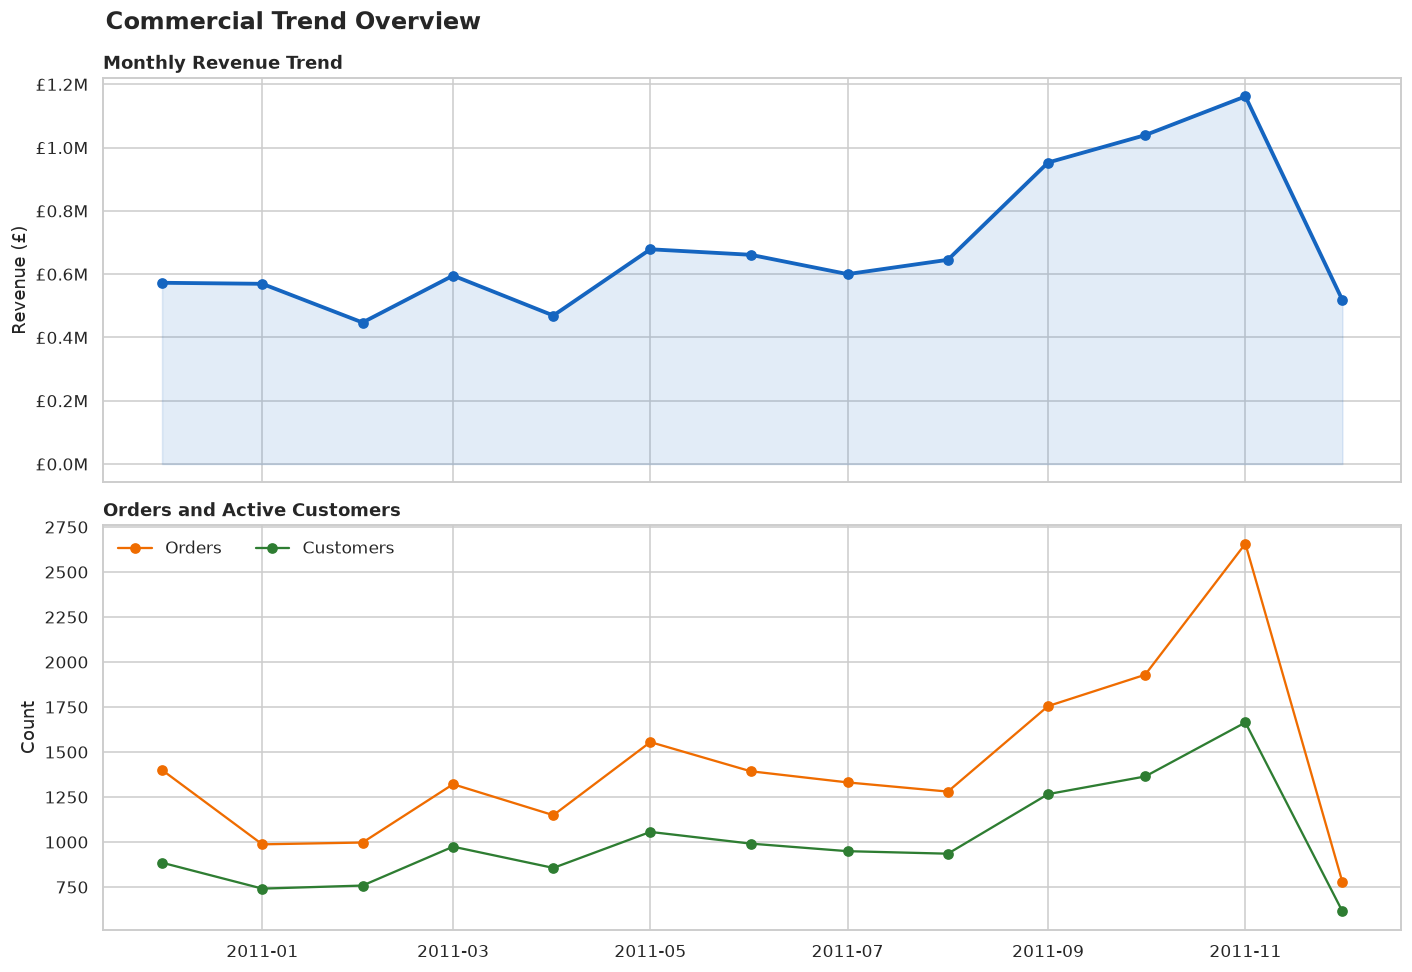

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].plot(monthly["InvoiceMonth"], monthly["Revenue"], marker="o", linewidth=2.5, color="#1565C0")
axes[0].fill_between(monthly["InvoiceMonth"], monthly["Revenue"], alpha=0.12, color="#1565C0")
axes[0].set_title("Monthly Revenue Trend", loc="left", weight="bold")
axes[0].set_ylabel("Revenue (£)")
axes[0].yaxis.set_major_formatter(lambda value, _: f"£{value/1_000_000:.1f}M")

axes[1].plot(monthly["InvoiceMonth"], monthly["Orders"], marker="o", label="Orders", color="#EF6C00")
axes[1].plot(monthly["InvoiceMonth"], monthly["Customers"], marker="o", label="Customers", color="#2E7D32")
axes[1].set_title("Orders and Active Customers", loc="left", weight="bold")
axes[1].set_ylabel("Count")
axes[1].legend(frameon=False, ncol=2)

fig.suptitle("Commercial Trend Overview", fontsize=16, weight="bold", x=0.08, ha="left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_monthly_sales_trend.png", bbox_inches="tight")
plt.show()


In [6]:
# A compact pivot table: top countries by monthly revenue.
country_revenue = (
    sales.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
top_countries = country_revenue.head(10).index
country_month_pivot = pd.pivot_table(
    sales[sales["Country"].isin(top_countries)],
    index="Country",
    columns="InvoiceMonth",
    values="Revenue",
    aggfunc="sum",
    fill_value=0,
).reindex(country_revenue.head(10).index)

display(country_month_pivot.style.format("£{:,.0f}"))


InvoiceMonth,2010-12-01 00:00:00,2011-01-01 00:00:00,2011-02-01 00:00:00,2011-03-01 00:00:00,2011-04-01 00:00:00,2011-05-01 00:00:00,2011-06-01 00:00:00,2011-07-01 00:00:00,2011-08-01 00:00:00,2011-09-01 00:00:00,2011-10-01 00:00:00,2011-11-01 00:00:00,2011-12-01 00:00:00
Country,,,,,,,,,,,,,
United Kingdom,"£498,662","£442,190","£355,656","£467,199","£409,559","£551,569","£524,915","£485,612","£498,453","£796,780","£824,766","£980,646","£472,384"
Netherlands,"£8,784","£26,611","£23,012","£22,416","£2,977","£29,186","£26,858",£26,"£40,328","£26,937","£40,709","£25,874","£11,728"
EIRE,"£8,814","£21,904","£10,127","£21,674","£7,570","£15,982","£19,836","£40,905","£16,967","£40,995","£24,318","£29,473","£6,979"
Germany,"£15,241","£16,911","£9,581","£14,393","£12,316","£25,751","£13,274","£16,441","£19,221","£18,091","£31,638","£28,025","£7,984"
France,"£9,616","£17,740","£8,516","£14,590","£5,530","£17,615","£16,079","£10,000","£13,811","£23,428","£33,485","£31,337","£7,277"
Australia,"£1,033","£9,018","£14,695","£17,224",£772,"£13,638","£25,188","£4,964","£22,489","£5,107","£17,151","£7,243",£0
Spain,"£1,844","£10,086","£2,114","£5,363","£1,786","£3,258","£3,333","£7,625","£3,347","£5,189","£8,637","£8,679",£316
Switzerland,"£1,305","£4,231","£2,655","£1,870","£2,077","£3,610","£7,904","£3,763","£4,970","£8,285","£7,655","£8,119",£0
Belgium,"£1,810","£1,200","£2,181","£3,352","£1,989","£2,732","£4,275","£2,476","£3,554","£4,208","£5,685","£6,316","£1,418"


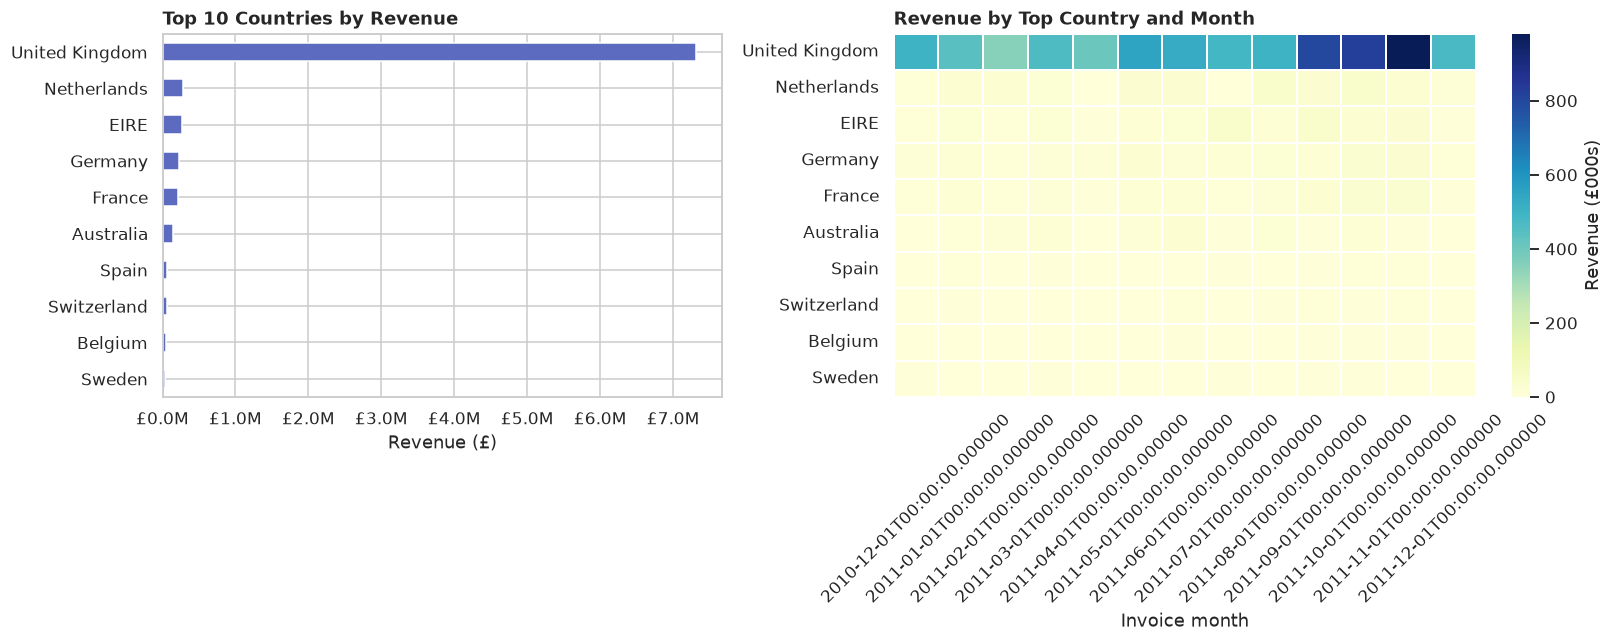

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.3]})

country_revenue.head(10).sort_values().plot.barh(ax=axes[0], color="#5C6BC0")
axes[0].set_title("Top 10 Countries by Revenue", loc="left", weight="bold")
axes[0].set_xlabel("Revenue (£)")
axes[0].xaxis.set_major_formatter(lambda value, _: f"£{value/1_000_000:.1f}M")
axes[0].set_ylabel("")

sns.heatmap(
    country_month_pivot / 1_000,
    cmap="YlGnBu",
    linewidths=0.3,
    ax=axes[1],
    cbar_kws={"label": "Revenue (£000s)"},
)
axes[1].set_title("Revenue by Top Country and Month", loc="left", weight="bold")
axes[1].set_xlabel("Invoice month")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_country_performance.png", bbox_inches="tight")
plt.show()


,,Revenue,Units,Orders
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE","£168,470",80995,1
22423,REGENCY CAKESTAND 3 TIER,"£142,593",12402,1703
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£100,448",36725,1971
85099B,JUMBO BAG RED RETROSPOT,"£85,221",46181,1600
23166,MEDIUM CERAMIC TOP STORAGE JAR,"£81,417",77916,195
POST,POSTAGE,"£77,804",3120,1099
47566,PARTY BUNTING,"£68,844",15291,1379
84879,ASSORTED COLOUR BIRD ORNAMENT,"£56,580",35362,1375
M,Manual,"£53,780",7173,253


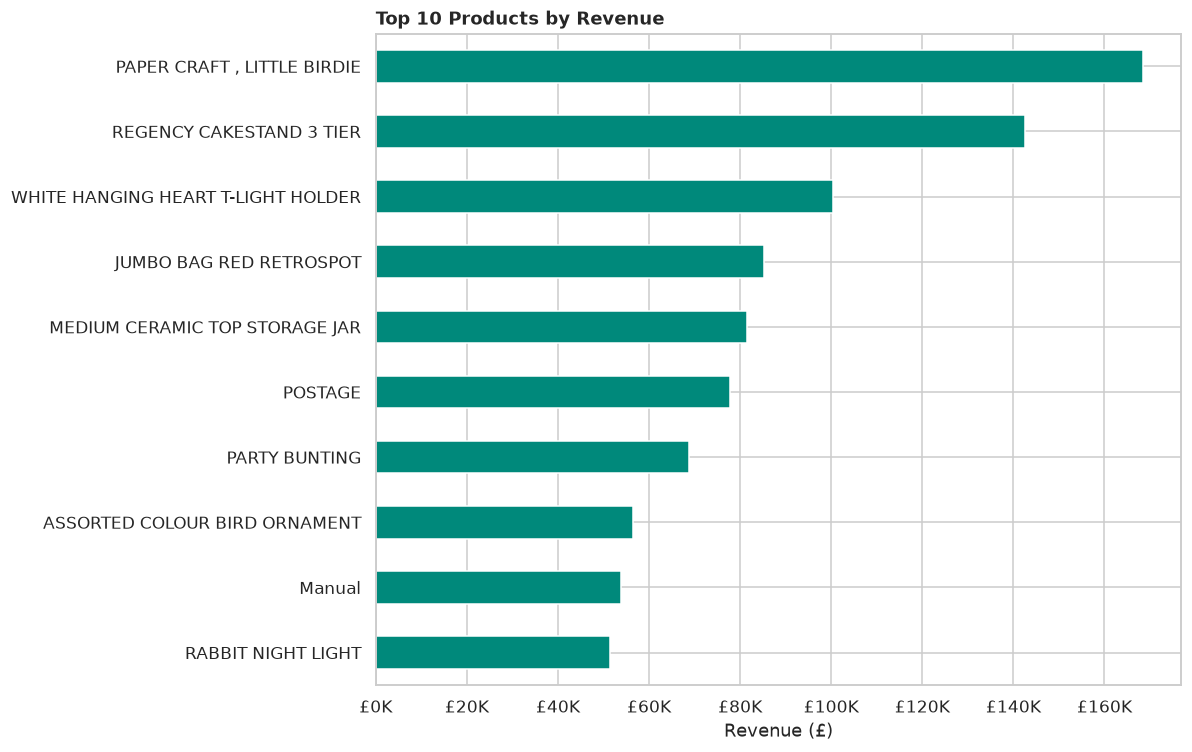

In [8]:
product_revenue = (
    sales.groupby(["StockCode", "Description"], dropna=False)
    .agg(Revenue=("Revenue", "sum"), Units=("Quantity", "sum"), Orders=("InvoiceNo", "nunique"))
    .sort_values("Revenue", ascending=False)
)
display(product_revenue.head(15).style.format({"Revenue": "£{:,.0f}"}))

fig, ax = plt.subplots(figsize=(11, 7))
product_revenue.head(10).sort_values("Revenue").plot.barh(
    y="Revenue", ax=ax, legend=False, color="#00897B"
)
ax.set_title("Top 10 Products by Revenue", loc="left", weight="bold")
ax.set_xlabel("Revenue (£)")
ax.xaxis.set_major_formatter(lambda value, _: f"£{value/1_000:.0f}K")
ax.set_ylabel("")
ax.set_yticklabels([label[:45] for label in product_revenue.head(10).sort_values("Revenue").index.get_level_values("Description")])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_top_products.png", bbox_inches="tight")
plt.show()


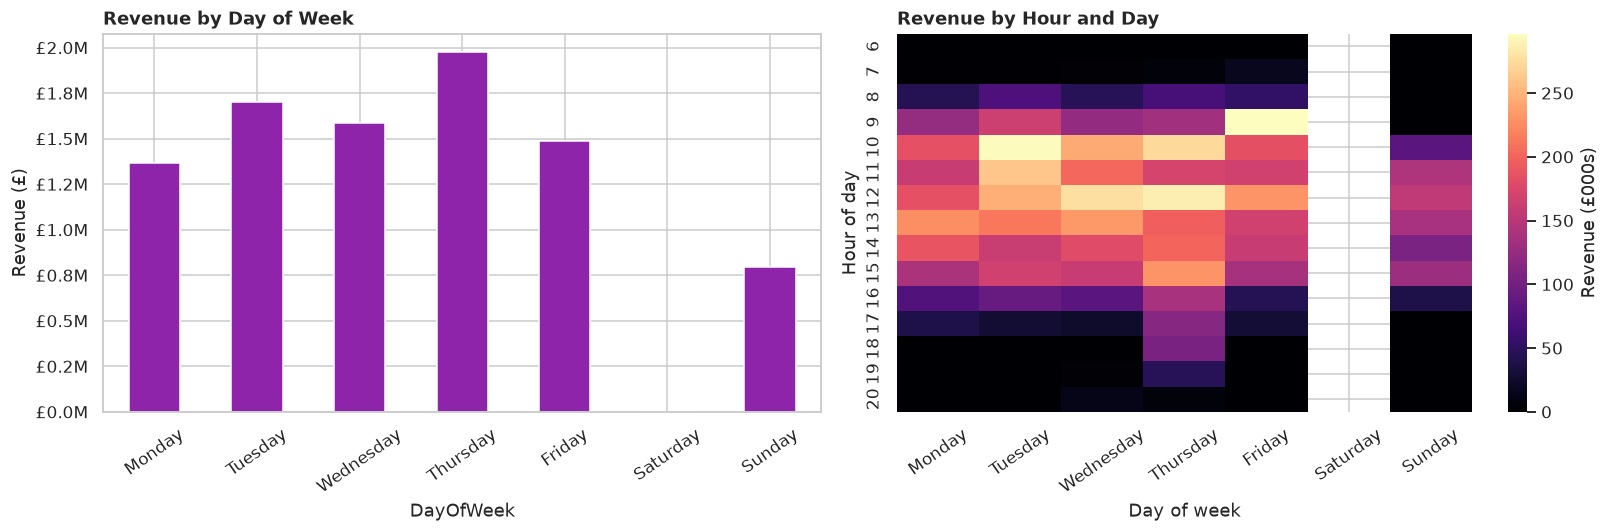

In [9]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_revenue = sales.groupby("DayOfWeek")["Revenue"].sum().reindex(weekday_order)
hour_day_pivot = pd.pivot_table(
    sales,
    index="Hour",
    columns="DayOfWeek",
    values="Revenue",
    aggfunc="sum",
    fill_value=0,
).reindex(columns=weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
weekday_revenue.plot.bar(ax=axes[0], color="#8E24AA")
axes[0].set_title("Revenue by Day of Week", loc="left", weight="bold")
axes[0].set_ylabel("Revenue (£)")
axes[0].yaxis.set_major_formatter(lambda value, _: f"£{value/1_000_000:.1f}M")
axes[0].tick_params(axis="x", rotation=35)

sns.heatmap(
    hour_day_pivot / 1_000,
    cmap="magma",
    ax=axes[1],
    cbar_kws={"label": "Revenue (£000s)"},
)
axes[1].set_title("Revenue by Hour and Day", loc="left", weight="bold")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Hour of day")
axes[1].tick_params(axis="x", rotation=35)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_time_patterns.png", bbox_inches="tight")
plt.show()


## 4. Customer segmentation and churn-risk proxy

In [10]:
# One row per customer: recency, frequency, and monetary value.
snapshot_date = sales["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

customer_metrics = (
    sales.groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
        Units=("Quantity", "sum"),
        ProductVariety=("StockCode", "nunique"),
        Country=("Country", "first"),
    )
    .reset_index()
)
customer_metrics["RecencyDays"] = (
    snapshot_date - customer_metrics["LastPurchase"].dt.normalize()
).dt.days
customer_metrics["AverageOrderValue"] = (
    customer_metrics["Monetary"] / customer_metrics["Frequency"]
)

def quartile_score(series, ascending=True):
    ranks = series.rank(method="first", ascending=ascending)
    return pd.qcut(ranks, 4, labels=[1, 2, 3, 4]).astype(int)

customer_metrics["R_Score"] = quartile_score(customer_metrics["RecencyDays"], ascending=False)
customer_metrics["F_Score"] = quartile_score(customer_metrics["Frequency"], ascending=True)
customer_metrics["M_Score"] = quartile_score(customer_metrics["Monetary"], ascending=True)
customer_metrics["RFM_Score"] = (
    customer_metrics["R_Score"].astype(str)
    + customer_metrics["F_Score"].astype(str)
    + customer_metrics["M_Score"].astype(str)
)

segment_conditions = [
    (customer_metrics["R_Score"] >= 3) & (customer_metrics["F_Score"] >= 3) & (customer_metrics["M_Score"] >= 3),
    (customer_metrics["F_Score"] >= 3) & (customer_metrics["M_Score"] >= 2),
    (customer_metrics["R_Score"] >= 3) & (customer_metrics["F_Score"] >= 2),
    (customer_metrics["R_Score"] >= 3) & (customer_metrics["F_Score"] <= 2),
    (customer_metrics["R_Score"] <= 2) & (customer_metrics["F_Score"] >= 2),
]
segment_labels = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "At Risk",
]
customer_metrics["Segment"] = np.select(segment_conditions, segment_labels, default="Hibernating")

customer_metrics["ChurnRisk"] = pd.cut(
    customer_metrics["RecencyDays"],
    bins=[-1, 30, 60, 90, np.inf],
    labels=["Active (0–30d)", "Cooling (31–60d)", "At Risk (61–90d)", "Churn Proxy (>90d)"],
)

display(
    customer_metrics[
        [
            "CustomerID",
            "RecencyDays",
            "Frequency",
            "Monetary",
            "AverageOrderValue",
            "RFM_Score",
            "Segment",
            "ChurnRisk",
        ]
    ].sort_values("Monetary", ascending=False).head(15).style.format(
        {"Monetary": "£{:,.0f}", "AverageOrderValue": "£{:,.2f}"}
    )
)


,CustomerID,RecencyDays,Frequency,Monetary,AverageOrderValue,RFM_Score,Segment,ChurnRisk
1689,14646.0,2,73,"£280,206","£3,838.44",444,Champions,Active (0–30d)
4201,18102.0,1,60,"£259,657","£4,327.62",444,Champions,Active (0–30d)
3728,17450.0,9,46,"£194,551","£4,229.36",444,Champions,Active (0–30d)
3008,16446.0,1,2,"£168,472","£84,236.25",424,Potential Loyalists,Active (0–30d)
1879,14911.0,2,201,"£143,825",£715.55,444,Champions,Active (0–30d)
55,12415.0,25,21,"£124,915","£5,948.31",344,Champions,Active (0–30d)
1333,14156.0,10,55,"£117,380","£2,134.18",444,Champions,Active (0–30d)
3771,17511.0,3,31,"£91,062","£2,937.50",444,Champions,Active (0–30d)
2702,16029.0,39,63,"£81,025","£1,286.11",344,Champions,Cooling (31–60d)
0,12346.0,326,1,"£77,184","£77,183.60",114,Hibernating,Churn Proxy (>90d)


In [11]:
segment_summary = (
    customer_metrics.groupby("Segment", observed=True)
    .agg(
        Customers=("CustomerID", "nunique"),
        Revenue=("Monetary", "sum"),
        AvgRevenue=("Monetary", "mean"),
        AvgRecencyDays=("RecencyDays", "mean"),
        AvgFrequency=("Frequency", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)
segment_summary["RevenueSharePct"] = segment_summary["Revenue"] / sales["Revenue"].sum() * 100
display(
    segment_summary.style.format(
        {
            "Revenue": "£{:,.0f}",
            "AvgRevenue": "£{:,.0f}",
            "AvgRecencyDays": "{:,.0f}",
            "AvgFrequency": "{:,.1f}",
            "RevenueSharePct": "{:,.1f}%",
        }
    )
)

risk_summary = (
    customer_metrics.groupby("ChurnRisk", observed=True)
    .agg(Customers=("CustomerID", "nunique"), Revenue=("Monetary", "sum"))
)
risk_summary["RevenueSharePct"] = risk_summary["Revenue"] / sales["Revenue"].sum() * 100
display(
    risk_summary.style.format(
        {"Revenue": "£{:,.0f}", "RevenueSharePct": "{:,.1f}%"}
    )
)


,Customers,Revenue,AvgRevenue,AvgRecencyDays,AvgFrequency,RevenueSharePct
Segment,,,,,,
Champions,1317,"£6,500,458","£4,936",18,9.4,72.9%
Loyal Customers,766,"£1,123,743","£1,467",96,4.0,12.6%
Potential Loyalists,434,"£411,747",£949,24,1.8,4.6%
Hibernating,832,"£398,191",£479,196,1.0,4.5%
At Risk,736,"£387,026",£526,172,1.6,4.3%
New Customers,253,"£90,242",£357,27,1.0,1.0%


,Customers,Revenue,RevenueSharePct
ChurnRisk,,,
Active (0–30d),1628,"£6,237,843",70.0%
Cooling (31–60d),748,"£1,097,395",12.3%
At Risk (61–90d),513,"£540,899",6.1%
Churn Proxy (>90d),1449,"£1,035,270",11.6%


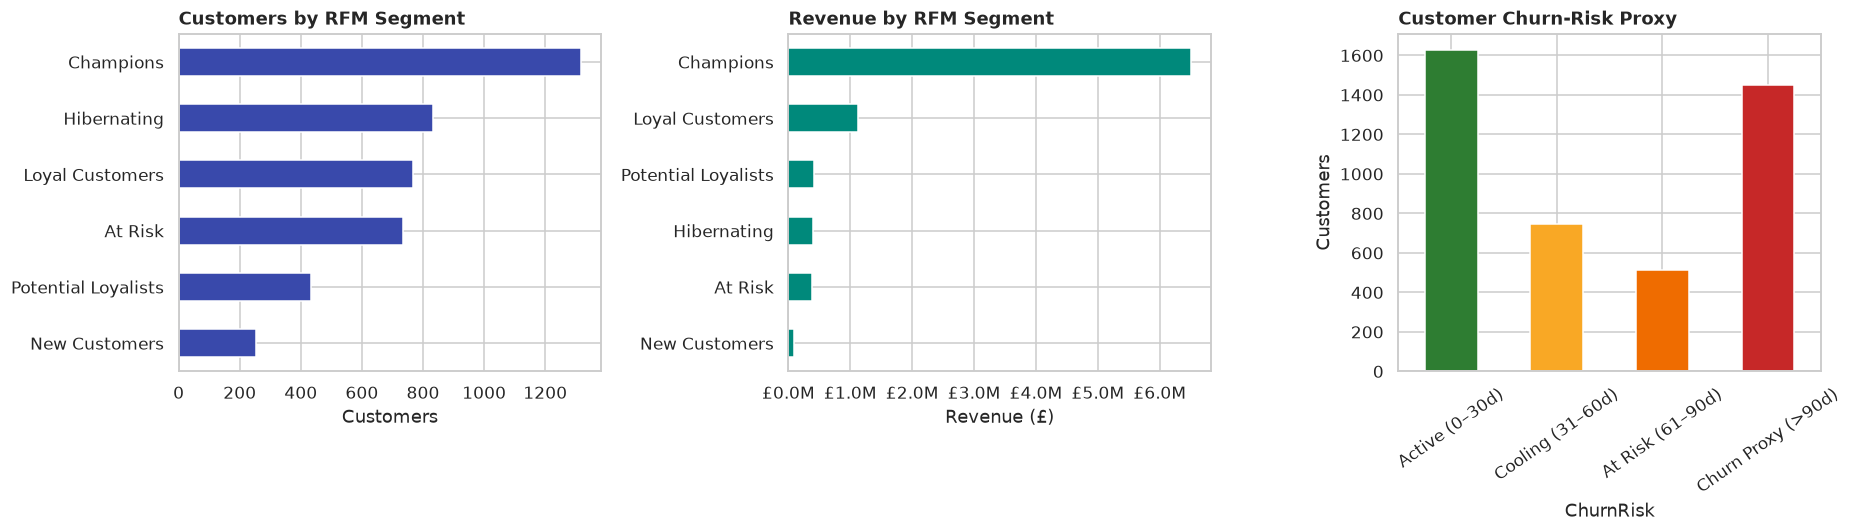

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

segment_summary["Customers"].sort_values().plot.barh(ax=axes[0], color="#3949AB")
axes[0].set_title("Customers by RFM Segment", loc="left", weight="bold")
axes[0].set_xlabel("Customers")
axes[0].set_ylabel("")

segment_summary["Revenue"].sort_values().plot.barh(ax=axes[1], color="#00897B")
axes[1].set_title("Revenue by RFM Segment", loc="left", weight="bold")
axes[1].set_xlabel("Revenue (£)")
axes[1].xaxis.set_major_formatter(lambda value, _: f"£{value/1_000_000:.1f}M")
axes[1].set_ylabel("")

risk_summary["Customers"].plot.bar(ax=axes[2], color=["#2E7D32", "#F9A825", "#EF6C00", "#C62828"])
axes[2].set_title("Customer Churn-Risk Proxy", loc="left", weight="bold")
axes[2].set_ylabel("Customers")
axes[2].tick_params(axis="x", rotation=35)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_customer_segments_and_risk.png", bbox_inches="tight")
plt.show()


## 5. New vs. returning customers and cohort retention

CustomerType,New,Returning,TotalActiveCustomers,ReturningSharePct
InvoiceMonth,,,,
2010-12-01 00:00:00,885,0,885,0.0%
2011-01-01 00:00:00,417,324,741,43.7%
2011-02-01 00:00:00,380,378,758,49.9%
2011-03-01 00:00:00,452,522,974,53.6%
2011-04-01 00:00:00,300,556,856,65.0%
2011-05-01 00:00:00,284,772,1056,73.1%
2011-06-01 00:00:00,242,749,991,75.6%
2011-07-01 00:00:00,188,761,949,80.2%
2011-08-01 00:00:00,169,766,935,81.9%


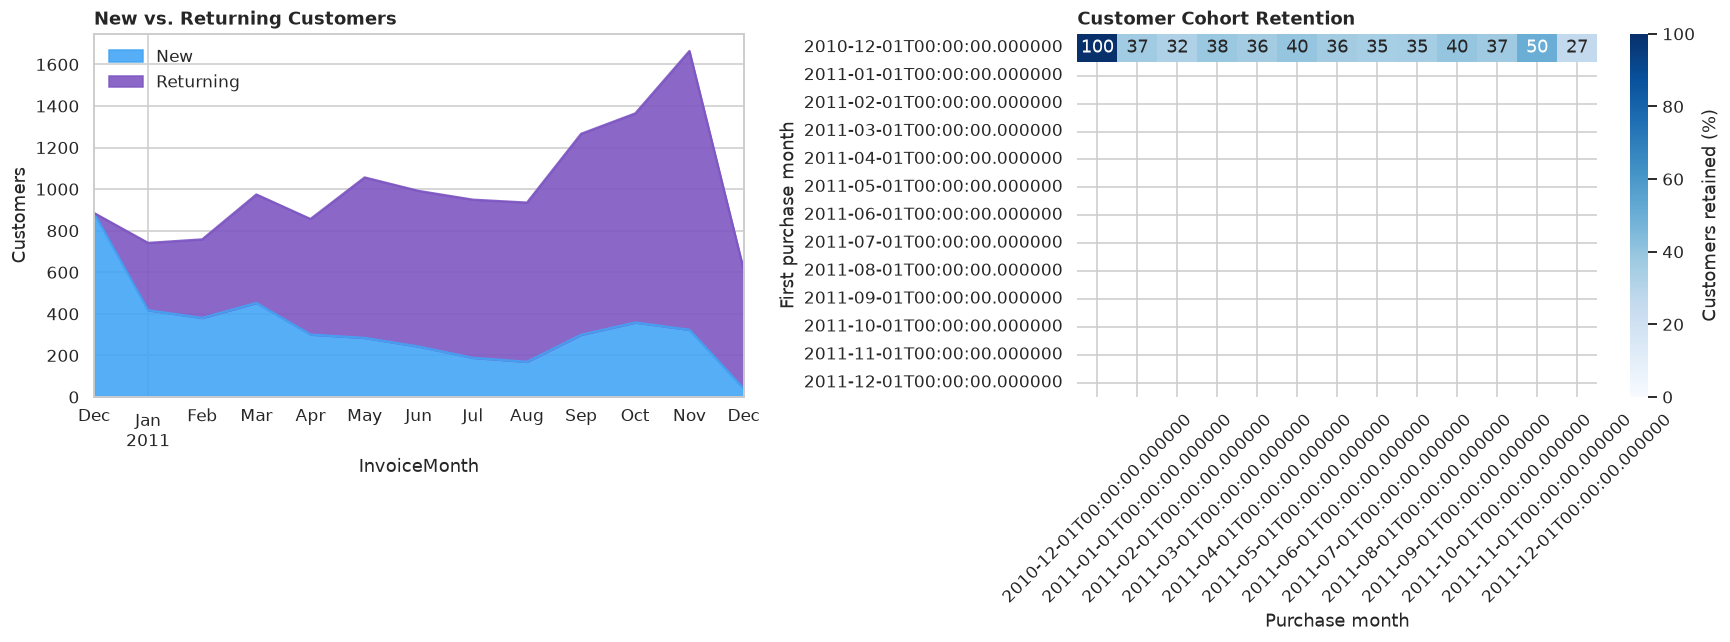

In [13]:
customer_month = sales[["CustomerID", "InvoiceMonth", "InvoiceNo"]].drop_duplicates()
first_purchase = (
    customer_month.groupby("CustomerID", as_index=False)["InvoiceMonth"]
    .min()
    .rename(columns={"InvoiceMonth": "FirstPurchaseMonth"})
)
customer_month = customer_month.merge(first_purchase, on="CustomerID", how="left")
customer_month["CustomerType"] = np.where(
    customer_month["InvoiceMonth"].eq(customer_month["FirstPurchaseMonth"]),
    "New",
    "Returning",
)

new_returning = (
    customer_month.groupby(["InvoiceMonth", "CustomerType"])["CustomerID"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["New", "Returning"], fill_value=0)
)
new_returning["TotalActiveCustomers"] = new_returning.sum(axis=1)
new_returning["ReturningSharePct"] = (
    new_returning["Returning"] / new_returning["TotalActiveCustomers"] * 100
)
display(new_returning.style.format({"ReturningSharePct": "{:,.1f}%"}))

cohort_counts = pd.pivot_table(
    customer_month,
    index="FirstPurchaseMonth",
    columns="InvoiceMonth",
    values="CustomerID",
    aggfunc="nunique",
    fill_value=0,
)
cohort_size = cohort_counts.iloc[:, 0].replace(0, np.nan)
cohort_retention = cohort_counts.divide(cohort_size, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
new_returning[["New", "Returning"]].plot.area(
    ax=axes[0], stacked=True, color=["#42A5F5", "#7E57C2"], alpha=0.9
)
axes[0].set_title("New vs. Returning Customers", loc="left", weight="bold")
axes[0].set_ylabel("Customers")
axes[0].legend(frameon=False)

sns.heatmap(
    cohort_retention,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Customers retained (%)"},
    ax=axes[1],
)
axes[1].set_title("Customer Cohort Retention", loc="left", weight="bold")
axes[1].set_xlabel("Purchase month")
axes[1].set_ylabel("First purchase month")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_retention_analysis.png", bbox_inches="tight")
plt.show()


## 6. Findings and actionable recommendations

In [14]:
def gbp(value):
    return f"£{value:,.0f}"

peak_month = monthly.loc[monthly["Revenue"].idxmax()]
best_growth_month = monthly.dropna(subset=["RevenueGrowthPct"]).loc[
    monthly.dropna(subset=["RevenueGrowthPct"])["RevenueGrowthPct"].idxmax()
]
top_country = country_revenue.index[0]
top_country_share = country_revenue.iloc[0] / sales["Revenue"].sum() * 100
top_product = product_revenue.index[0][1]
top_product_revenue = product_revenue.iloc[0]["Revenue"]
churn_proxy_customers = int((customer_metrics["ChurnRisk"] == "Churn Proxy (>90d)").sum())
churn_proxy_revenue = customer_metrics.loc[
    customer_metrics["ChurnRisk"] == "Churn Proxy (>90d)", "Monetary"
].sum()
returning_share = new_returning["ReturningSharePct"].mean()
repeat_customers = int((customer_metrics["Frequency"] >= 2).sum())
repeat_customer_share = repeat_customers / len(customer_metrics) * 100

findings = [
    f"**Scale:** The cleaned customer base contains **{len(customer_metrics):,} customers**, "
    f"**{sales['InvoiceNo'].nunique():,} completed orders**, and **{gbp(sales['Revenue'].sum())}** in net revenue.",
    f"**Peak demand:** **{peak_month['InvoiceMonth']:%B %Y}** was the strongest month at "
    f"**{gbp(peak_month['Revenue'])}**, with **{int(peak_month['Orders']):,} orders**.",
    f"**Geographic concentration:** **{top_country}** generated **{top_country_share:.1f}%** of revenue; "
    f"the top 10 countries together generated **{country_revenue.head(10).sum() / sales['Revenue'].sum() * 100:.1f}%**.",
    f"**Product concentration:** The top product, **{top_product[:55]}**, generated **{gbp(top_product_revenue)}**.",
    f"**Repeat behavior:** Customers with at least two orders represent **{repeat_customer_share:.1f}%** of customers; "
    f"the average monthly share of returning active customers is **{returning_share:.1f}%**.",
    f"**Retention risk:** **{churn_proxy_customers:,} customers** fall into the >90-day churn proxy, "
    f"representing **{gbp(churn_proxy_revenue)}** of historical customer revenue that could be recovered.",
]
display(Markdown("### Key findings\n\n" + "\n".join(f"- {item}" for item in findings)))

recommendations = [
    (
        "**Launch a win-back program for the churn proxy.**",
        f"Prioritize the {churn_proxy_customers:,} customers inactive for more than 90 days, "
        f"ranked by historical monetary value. Use a two-step offer: a personalized product reminder "
        f"first, then a time-limited incentive for non-responders. Measure recovered revenue against a holdout group."
    ),
    (
        "**Protect the high-value base.**",
        "Give Champions and Loyal Customers early access, replenishment reminders, and cross-sell bundles "
        "based on their product variety. This is more efficient than sending the same discount to every customer."
    ),
    (
        "**Plan inventory and campaigns around the demand peak.**",
        f"Use {peak_month['InvoiceMonth']:%B} as the starting point for stock, fulfillment, and campaign readiness. "
        f"Investigate the {best_growth_month['InvoiceMonth']:%B %Y} growth jump of "
        f"{best_growth_month['RevenueGrowthPct']:.1f}% to determine whether the driver was promotion, assortment, or seasonality."
    ),
    (
        "**Reduce geographic concentration risk.**",
        f"Keep the {top_country} core healthy, but test localized acquisition and shipping offers in the next-largest markets. "
        "Track contribution margin—not only revenue—before scaling."
    ),
    (
        "**Turn the product leaders into baskets, not single-item purchases.**",
        f"Use the top product ({top_product[:45]}) as an anchor for bundles and recommendations. "
        "Monitor attach rate, average order value, and margin to ensure the promotion increases basket economics."
    ),
]
display(Markdown("### Recommended actions\n\n" + "\n\n".join(
    f"{i}. {title} {detail}" for i, (title, detail) in enumerate(recommendations, start=1)
)))


### Key findings

- **Scale:** The cleaned customer base contains **4,338 customers**, **18,532 completed orders**, and **£8,911,408** in net revenue.
- **Peak demand:** **November 2011** was the strongest month at **£1,161,817**, with **2,657 orders**.
- **Geographic concentration:** **United Kingdom** generated **82.0%** of revenue; the top 10 countries together generated **96.9%**.
- **Product concentration:** The top product, **PAPER CRAFT , LITTLE BIRDIE**, generated **£168,470**.
- **Repeat behavior:** Customers with at least two orders represent **65.6%** of customers; the average monthly share of returning active customers is **65.2%**.
- **Retention risk:** **1,449 customers** fall into the >90-day churn proxy, representing **£1,035,270** of historical customer revenue that could be recovered.

### Recommended actions

1. **Launch a win-back program for the churn proxy.** Prioritize the 1,449 customers inactive for more than 90 days, ranked by historical monetary value. Use a two-step offer: a personalized product reminder first, then a time-limited incentive for non-responders. Measure recovered revenue against a holdout group.

2. **Protect the high-value base.** Give Champions and Loyal Customers early access, replenishment reminders, and cross-sell bundles based on their product variety. This is more efficient than sending the same discount to every customer.

3. **Plan inventory and campaigns around the demand peak.** Use November as the starting point for stock, fulfillment, and campaign readiness. Investigate the September 2011 growth jump of 47.6% to determine whether the driver was promotion, assortment, or seasonality.

4. **Reduce geographic concentration risk.** Keep the United Kingdom core healthy, but test localized acquisition and shipping offers in the next-largest markets. Track contribution margin—not only revenue—before scaling.

5. **Turn the product leaders into baskets, not single-item purchases.** Use the top product (PAPER CRAFT , LITTLE BIRDIE) as an anchor for bundles and recommendations. Monitor attach rate, average order value, and margin to ensure the promotion increases basket economics.

## 7. Limitations and next steps

- The 90-day churn proxy is a business rule, not a labeled churn outcome. A longer observation window and an explicit definition of reactivation would support a stronger churn model.
- Revenue is gross line-item revenue; the dataset does not provide cost, margin, shipping, refunds, marketing spend, or customer acquisition source.
- Customer IDs are missing for some rows, so the customer metrics cover identifiable customers rather than every transaction.
- The next production step would be to append newer transactions and track each segment monthly, with campaign exposure and margin joined to the customer table.

**Source:** [UCI Machine Learning Repository — Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)  
**Local data:** `data/Online_Retail.xlsx`  
**Outputs:** charts generated into `outputs/`
